In [29]:
import numpy as np
import matplotlib.pyplot as plt
import skimage
import os
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pickle
import pandas as pd
import glob
from run import OUTPUT_DIR

In [30]:
print(OUTPUT_DIR)
OUTPUT_DIR = 'mnist_no_early_stopping'

#choose parameters to graph
OUTPUT_DIR = 'mnist_no_early_stopping'
task_no = 0 # this is the task that the accuracy graph will be displayed for
params = {'exp_name' : ['mnist'], 'early_stopping_threshold': [100000]} # parameters to display
result_dir = 'plots'

GSS


In [31]:

def load_results():
    results = []
    for fname in glob.glob(f'{OUTPUT_DIR}/*/*'):
        # print('Reading from {}'.format(fname))
        if os.path.splitext(fname)[1] == '.pickle':  # Only try to unpickle .pickle files
            try:
                with open(fname, 'rb') as f:
                    result = pickle.load(f)
                    results.append(result)
            except (pickle.UnpicklingError, EOFError, AttributeError) as e:
                print(f"Error unpickling {fname}: {str(e)}")
        # else:
        #     print(f"Skipping non-pickle file: {fname}")
    
    df = pd.DataFrame(results)
    return df

results = load_results()

for param, values in params.items():
    results = results[results[param].isin(values)]
results = results.reset_index(drop=True)


In [32]:

def get_metric(df, p_val, method, metric):
    #returns the average and std for a given metric 
    p_value_df = df[df["p"] == p_val].reset_index(drop=True)
    method_metrics = p_value_df[method]
    metric_values = []
    for i in range(0, len(method_metrics)):         
         if metric == "Accuracy":
            metric_values.append(method_metrics[i]['M3 per task performance'][task_no])

         if metric == "M2 similarity":
             metric_values.append(method_metrics[i]['gradient similarities']['M2'])

         if metric == "M1 similarity":
             metric_values.append(method_metrics[i]['gradient similarities']['M1'])
             
    return metric_values

def get_metric_stats(metric_values):
    return np.average(metric_values), np.std(metric_values)

def aggregate_results(results):

    #get method names

    colnames = results.columns
    colnames_list = colnames.tolist()

    try:
        execution_time_index = colnames_list.index('execution_time')
    except ValueError:
        try:
            # If 'execution_time' is not found, look for 'p'
            execution_time_index = colnames_list.index('p')
        except ValueError:
            # If neither is found, use all column names
            execution_time_index = len(colnames_list)

    methods = colnames_list[:execution_time_index]
    method_names = methods

    metrics = ["Accuracy", "M1 similarity", "M2 similarity"]
    
    unique_p_values = results['p'].unique()
    
    processed_data = []
    
    for p in unique_p_values:
        for method, method_name in zip(methods, method_names):
            filtered_data = results[(results['p'] == p) & (results[method].notna())]
            
            if not filtered_data.empty:
                row_data = {
                    'p': p,
                    'method': method_name,
                    'samples': len(filtered_data)
                }
                
                for metric in metrics:
                    metric_values = get_metric(filtered_data, p, method, metric)
                    avg, std = get_metric_stats(metric_values)
                    
                    if metric == "Accuracy":
                        row_data['M3_task_avg'] = avg
                        row_data['M3_task_std'] = std
                        row_data['M3_task_array'] = metric_values
                    elif metric == "M1 similarity":
                        row_data['M1_grad_sim_avg'] = avg
                        row_data['M1_grad_sim_std'] = std
                        row_data['M1_grad_sim_array'] = metric_values
                    elif metric == "M2 similarity":
                        row_data['M2_grad_sim_avg'] = avg
                        row_data['M2_grad_sim_std'] = std
                        row_data['M2_grad_sim_array'] = metric_values
                
                processed_data.append(row_data)
    
    processed_df = pd.DataFrame(processed_data)
    
    return processed_df



In [33]:
aggregated_results = aggregate_results(results)

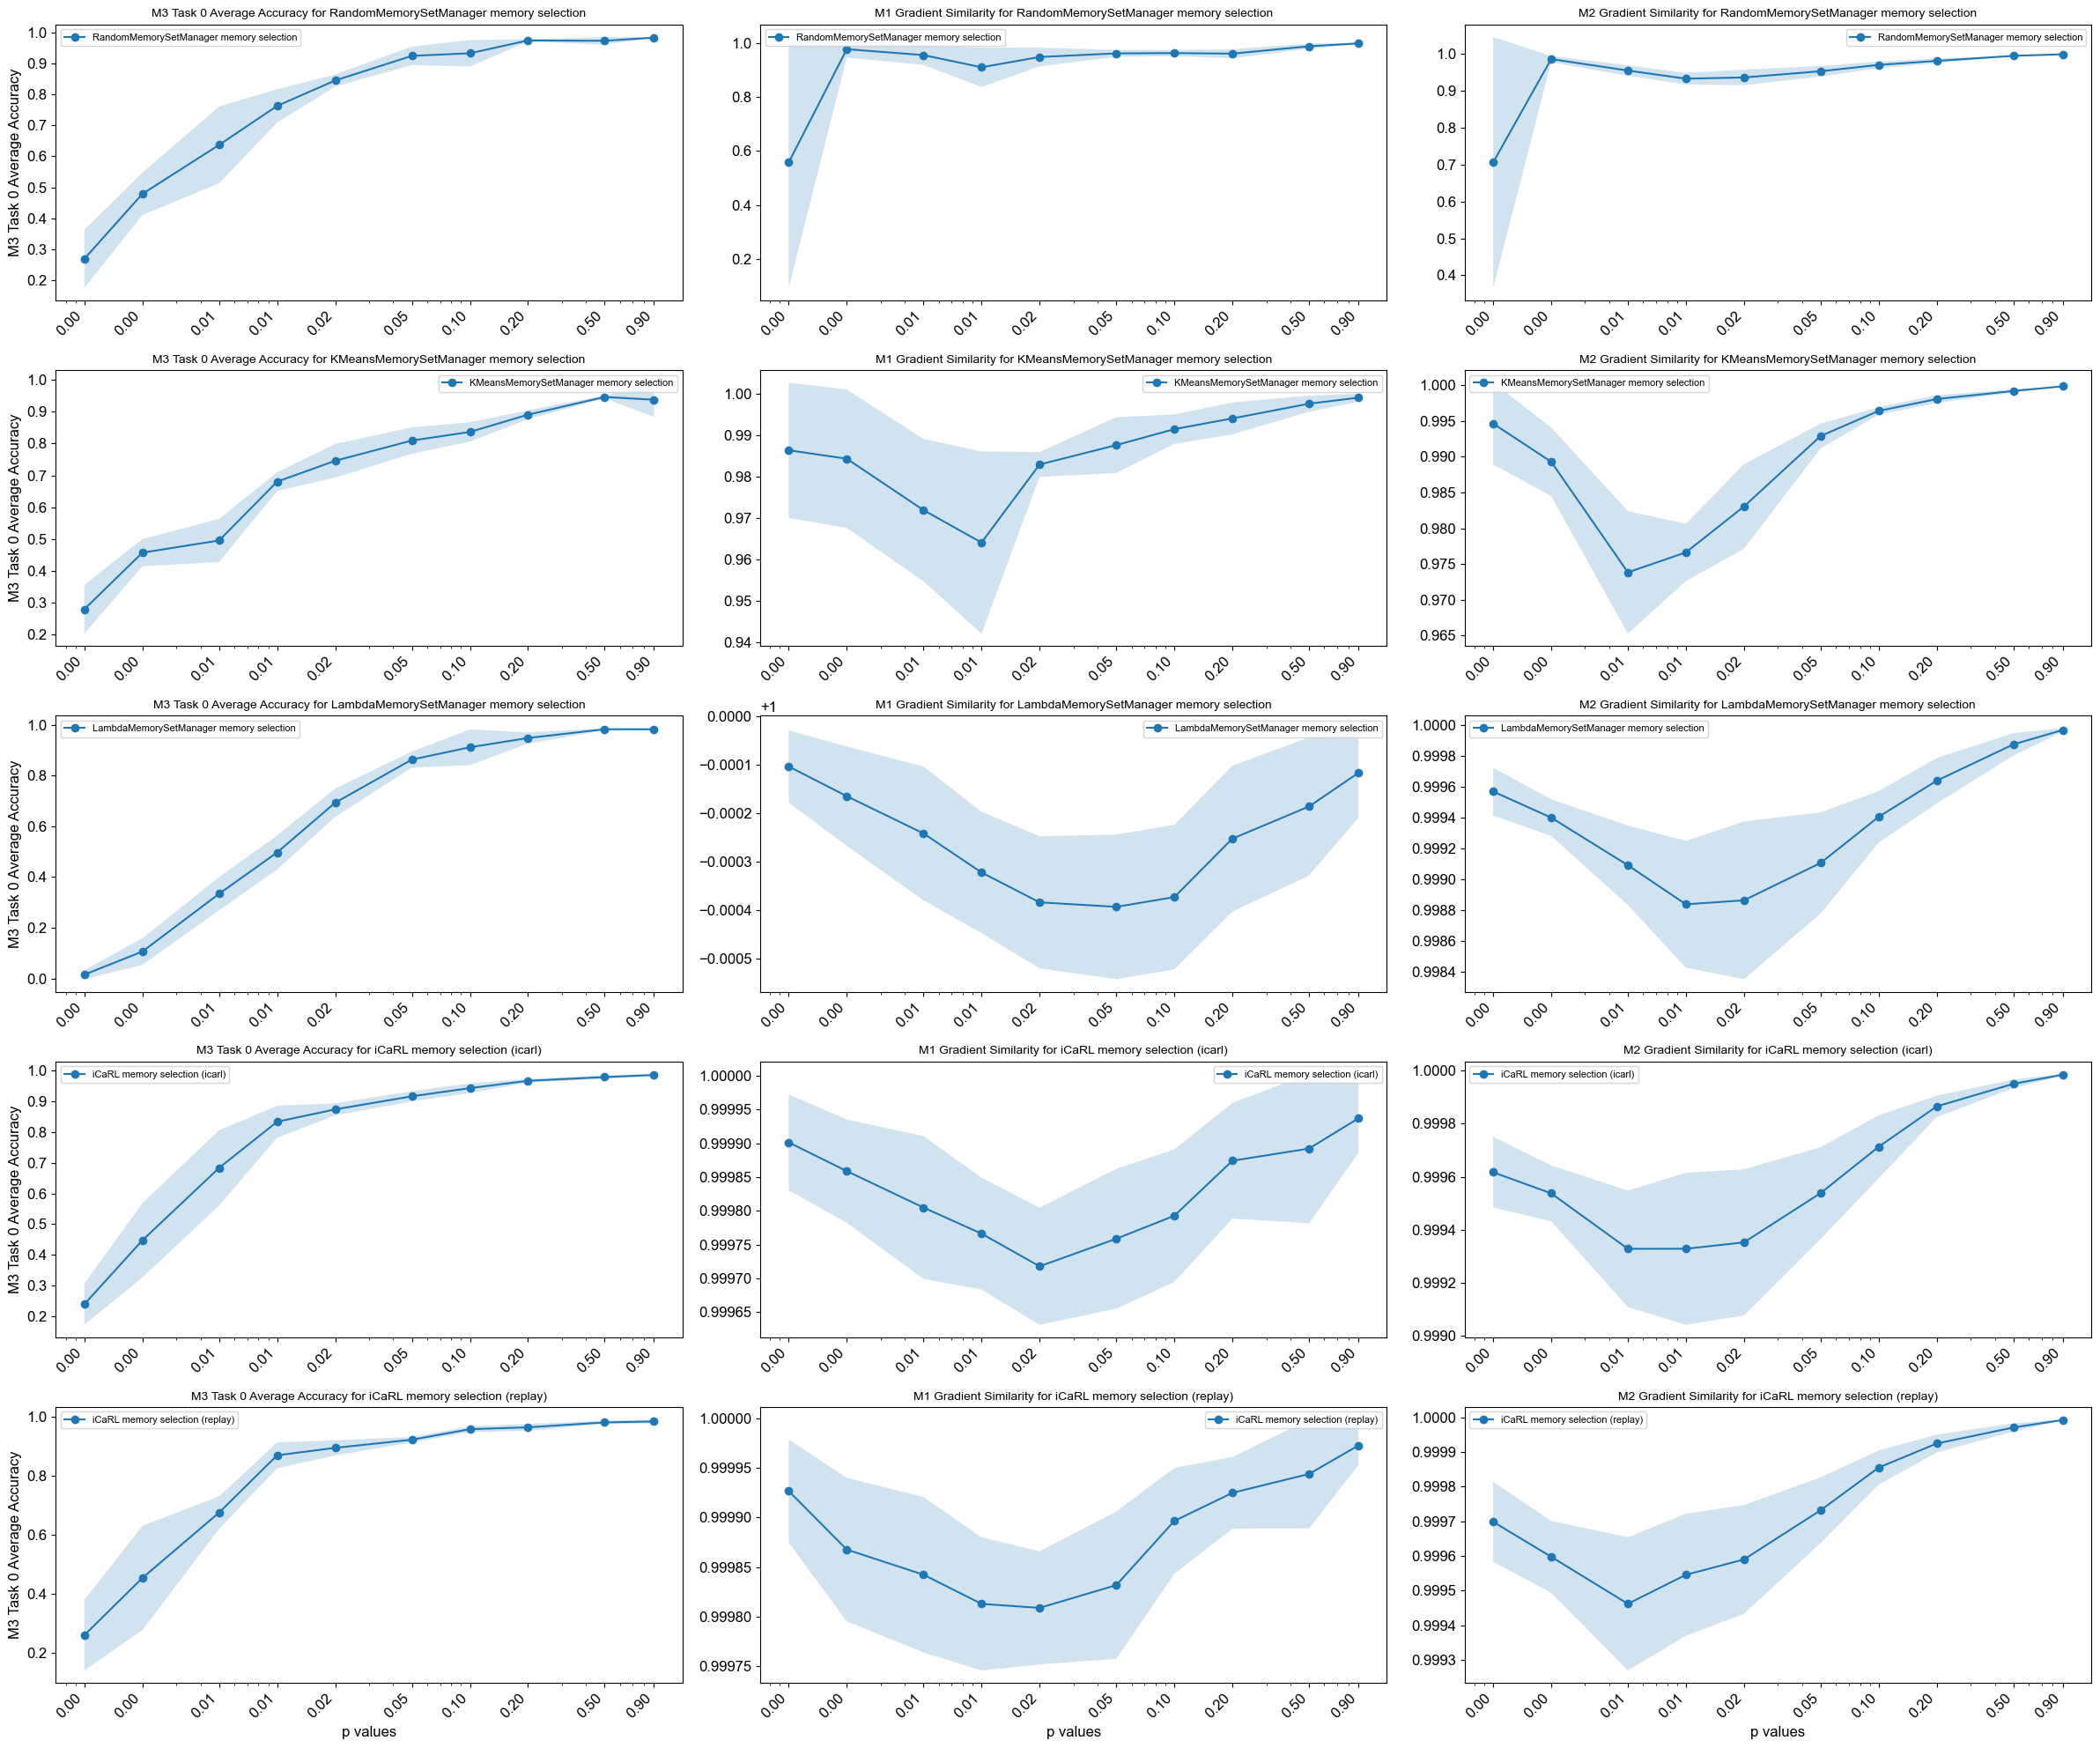

In [34]:

def plot_all_metrics(aggregated_results, dataset_name):
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12
    
    result_dir = f'gradient_similarity/{dataset_name}/plots'
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)
    
    methods = aggregated_results['method'].unique()
    p_vals = sorted(aggregated_results['p'].unique())
    
    num_methods = len(methods)
    fig, axs = plt.subplots(num_methods, 3, figsize=(24, 4*num_methods))
    
    metrics = ['M3_task', 'M1_grad_sim', 'M2_grad_sim']
    titles = [f'M3 Task {task_no} Average Accuracy', 'M1 Gradient Similarity', 'M2 Gradient Similarity']
    
    for method_index, method in enumerate(methods):
        method_data = aggregated_results[aggregated_results['method'] == method]
        
        for col, (metric, title) in enumerate(zip(metrics, titles)):
            if num_methods == 1:
                ax = axs[col]
            else:
                ax = axs[method_index, col]
            
            avg_values = [method_data[method_data['p'] == p][f'{metric}_avg'].values[0] for p in p_vals]
            std_values = [method_data[method_data['p'] == p][f'{metric}_std'].values[0] for p in p_vals]
            
            ax.plot(p_vals, avg_values, marker='o', label=method)
            ax.fill_between(p_vals, 
                            np.array(avg_values) - np.array(std_values), 
                            np.array(avg_values) + np.array(std_values), 
                            alpha=0.2)
            
            ax.set_xscale('log')
            ax.set_title(f'{title} for {method}', fontsize=10)
            ax.legend(fontsize=8)
            
            ax.set_xticks(p_vals)
            ax.set_xticklabels([f'{p:.2f}' for p in p_vals], rotation=45, ha='right')
            
            if method_index == num_methods - 1:  # Last row
                ax.set_xlabel('p values')
            
            if col == 0:  # First column
                ax.set_ylabel(title)
    
    plt.tight_layout()
    plt.savefig(f'{result_dir}/{OUTPUT_DIR}/{params['exp_name'][0]}/all_metrics_average.png')
    plt.show()

plot_all_metrics(aggregated_results, 'dataset_name')

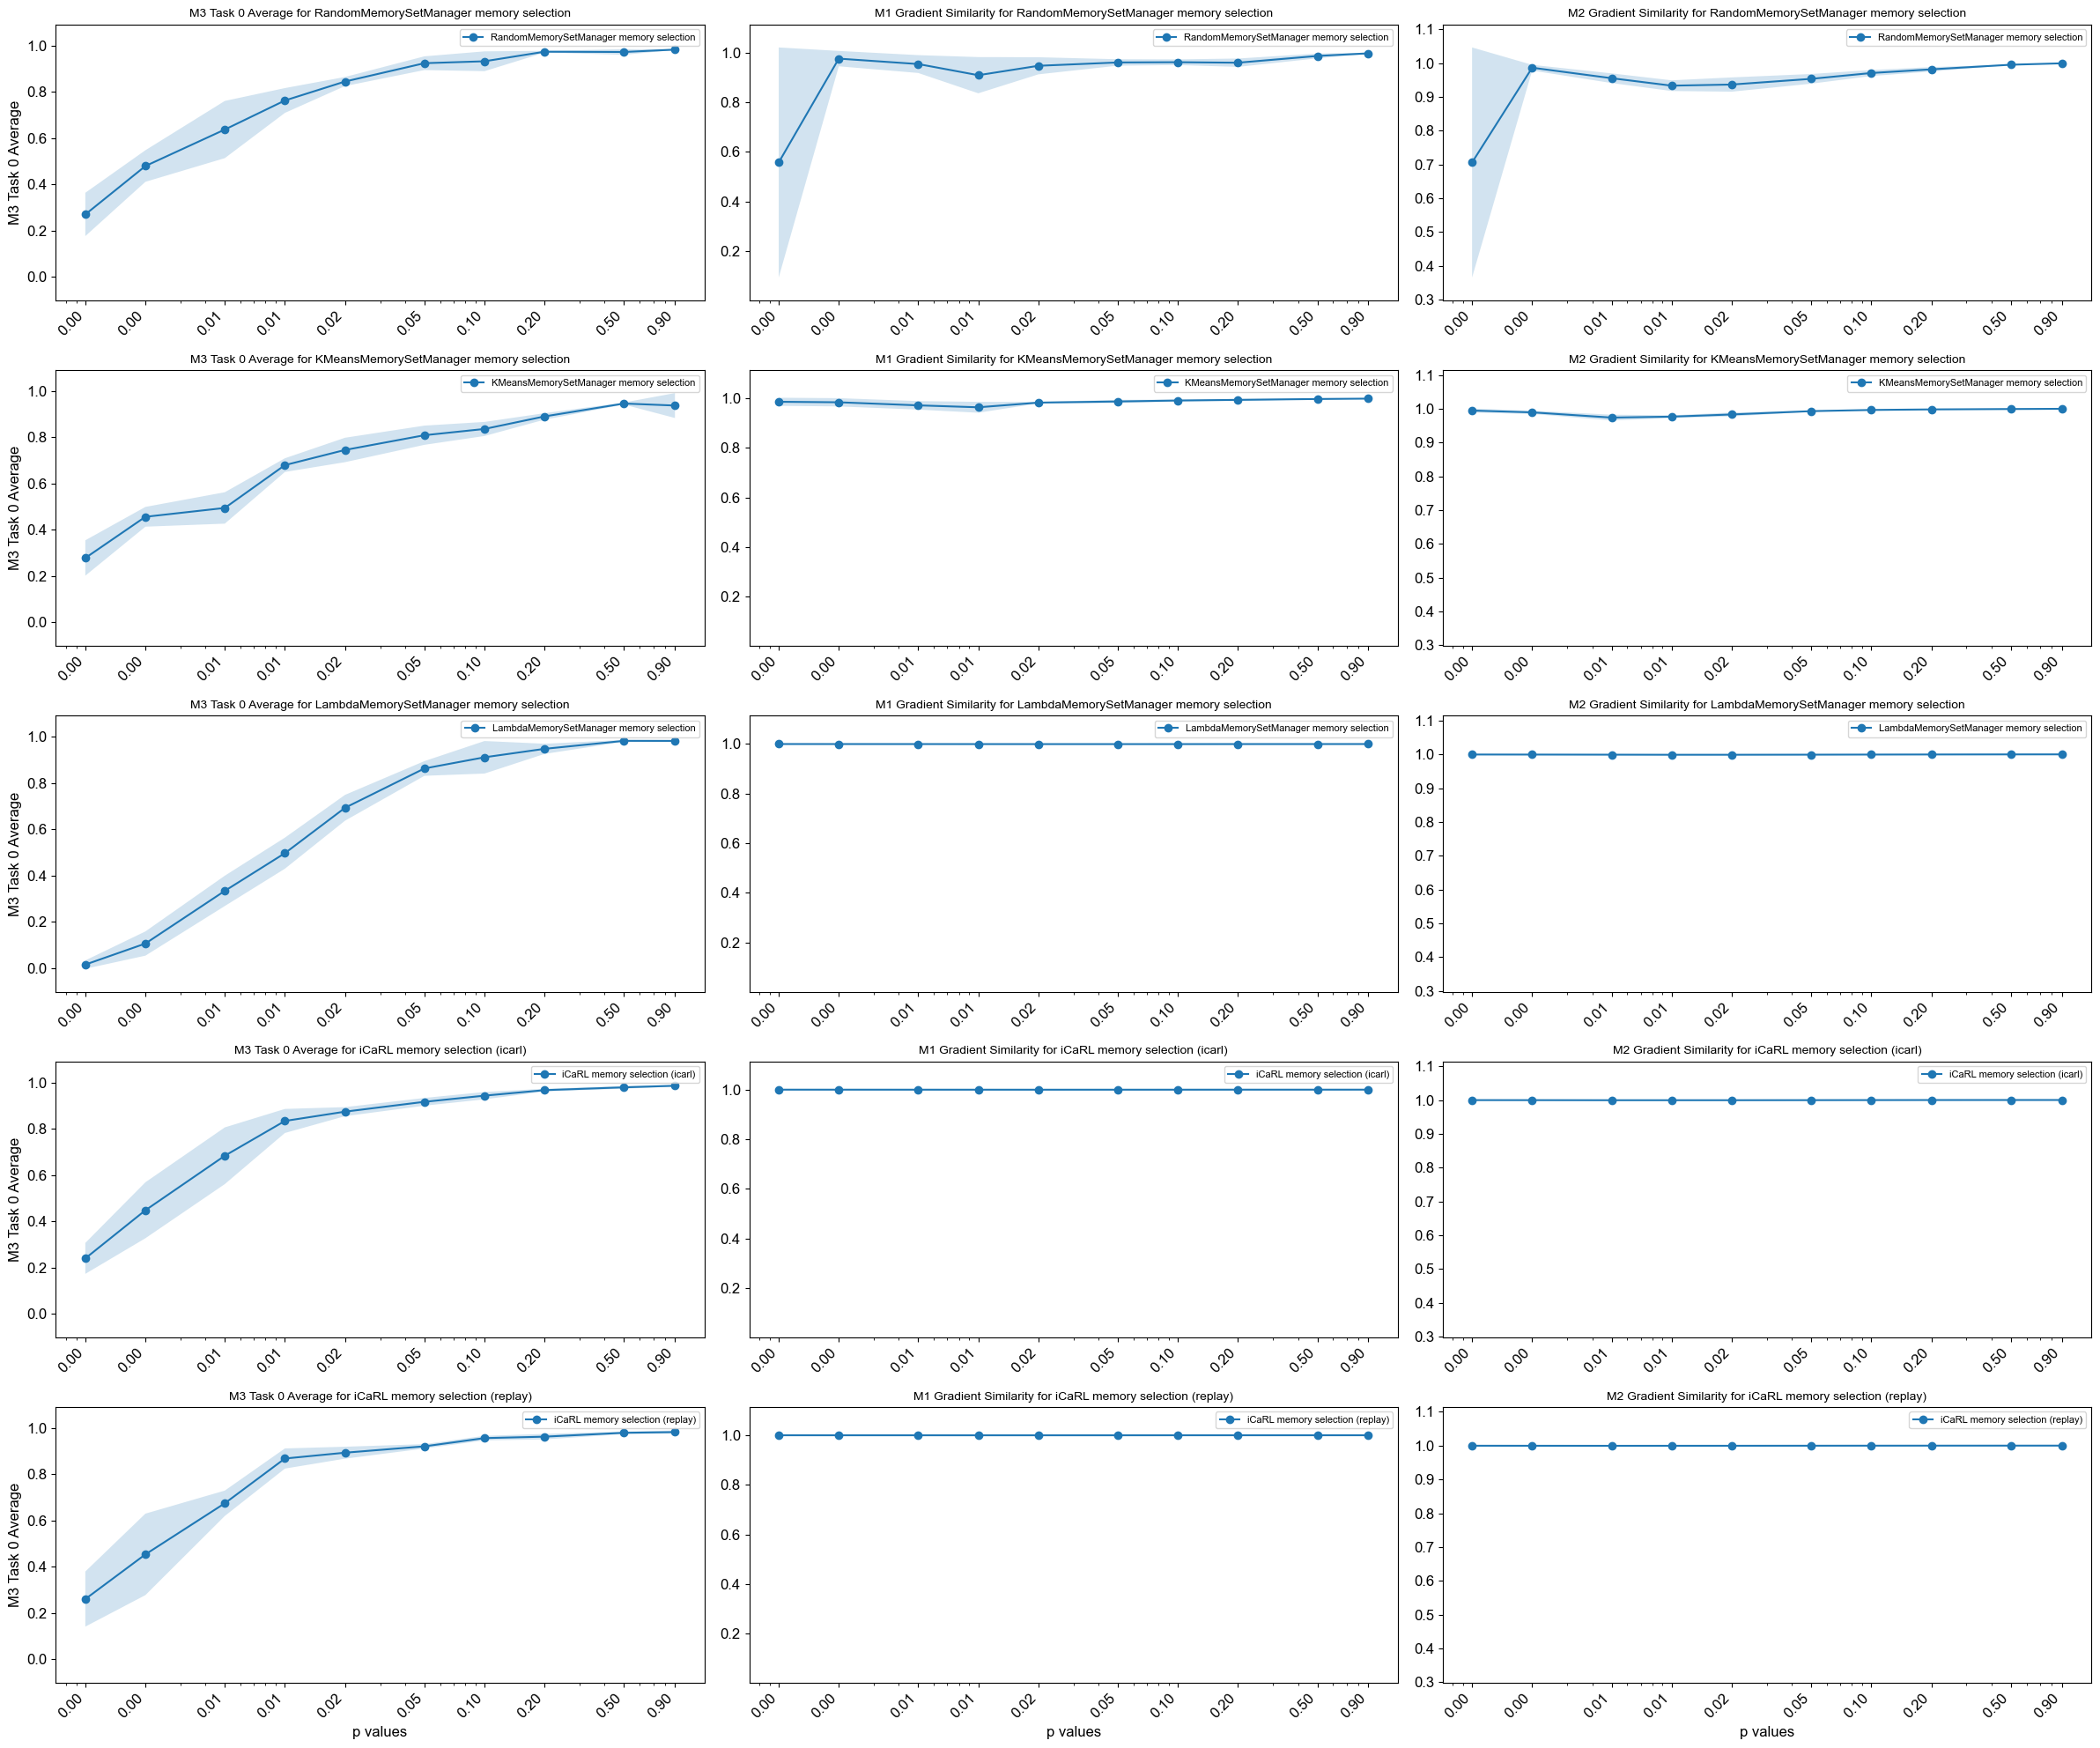

In [35]:

def plot_all_metrics_normalize_axis(aggregated_results, dataset_name):
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12
    
    result_dir = f'gradient_similarity/{dataset_name}/plots'
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)
    
    methods = aggregated_results['method'].unique()
    p_vals = sorted(aggregated_results['p'].unique())
    
    num_methods = len(methods)
    fig, axs = plt.subplots(num_methods, 3, figsize=(24, 4*num_methods))
    
    metrics = ['M3_task', 'M1_grad_sim', 'M2_grad_sim']
    titles = [f'M3 Task {task_no} Average', 'M1 Gradient Similarity', 'M2 Gradient Similarity']
    
    # Find global min and max for each metric, including std
    y_limits = {}
    for metric in metrics:
        min_val = (aggregated_results[f'{metric}_avg'] - aggregated_results[f'{metric}_std']).min()
        max_val = (aggregated_results[f'{metric}_avg'] + aggregated_results[f'{metric}_std']).max()
        y_range = max_val - min_val
        y_limits[metric] = (min_val - 0.1 * y_range, max_val + 0.1 * y_range)
    
    for method_index, method in enumerate(methods):
        method_data = aggregated_results[aggregated_results['method'] == method]
        
        for col, (metric, title) in enumerate(zip(metrics, titles)):
            if num_methods == 1:
                ax = axs[col]
            else:
                ax = axs[method_index, col]
            
            avg_values = [method_data[method_data['p'] == p][f'{metric}_avg'].values[0] for p in p_vals]
            std_values = [method_data[method_data['p'] == p][f'{metric}_std'].values[0] for p in p_vals]
            
            ax.plot(p_vals, avg_values, marker='o', label=method)
            ax.fill_between(p_vals, 
                            np.array(avg_values) - np.array(std_values), 
                            np.array(avg_values) + np.array(std_values), 
                            alpha=0.2)
            
            ax.set_xscale('log')
            ax.set_title(f'{title} for {method}', fontsize=10)
            ax.legend(fontsize=8)
            
            ax.set_xticks(p_vals)
            ax.set_xticklabels([f'{p:.2f}' for p in p_vals], rotation=45, ha='right')
            
            # Set y-axis limits to be the same for all methods within each metric
            ax.set_ylim(y_limits[metric])
            
            if method_index == num_methods - 1:  # Last row
                ax.set_xlabel('p values')
            
            if col == 0:  # First column
                ax.set_ylabel(title)
    
    plt.tight_layout()
    plt.savefig(f'{result_dir}/{OUTPUT_DIR}/{params['exp_name'][0]}/all_metrics_average.png')
    plt.show()

plot_all_metrics_normalize_axis(aggregated_results, 'dataset_name')

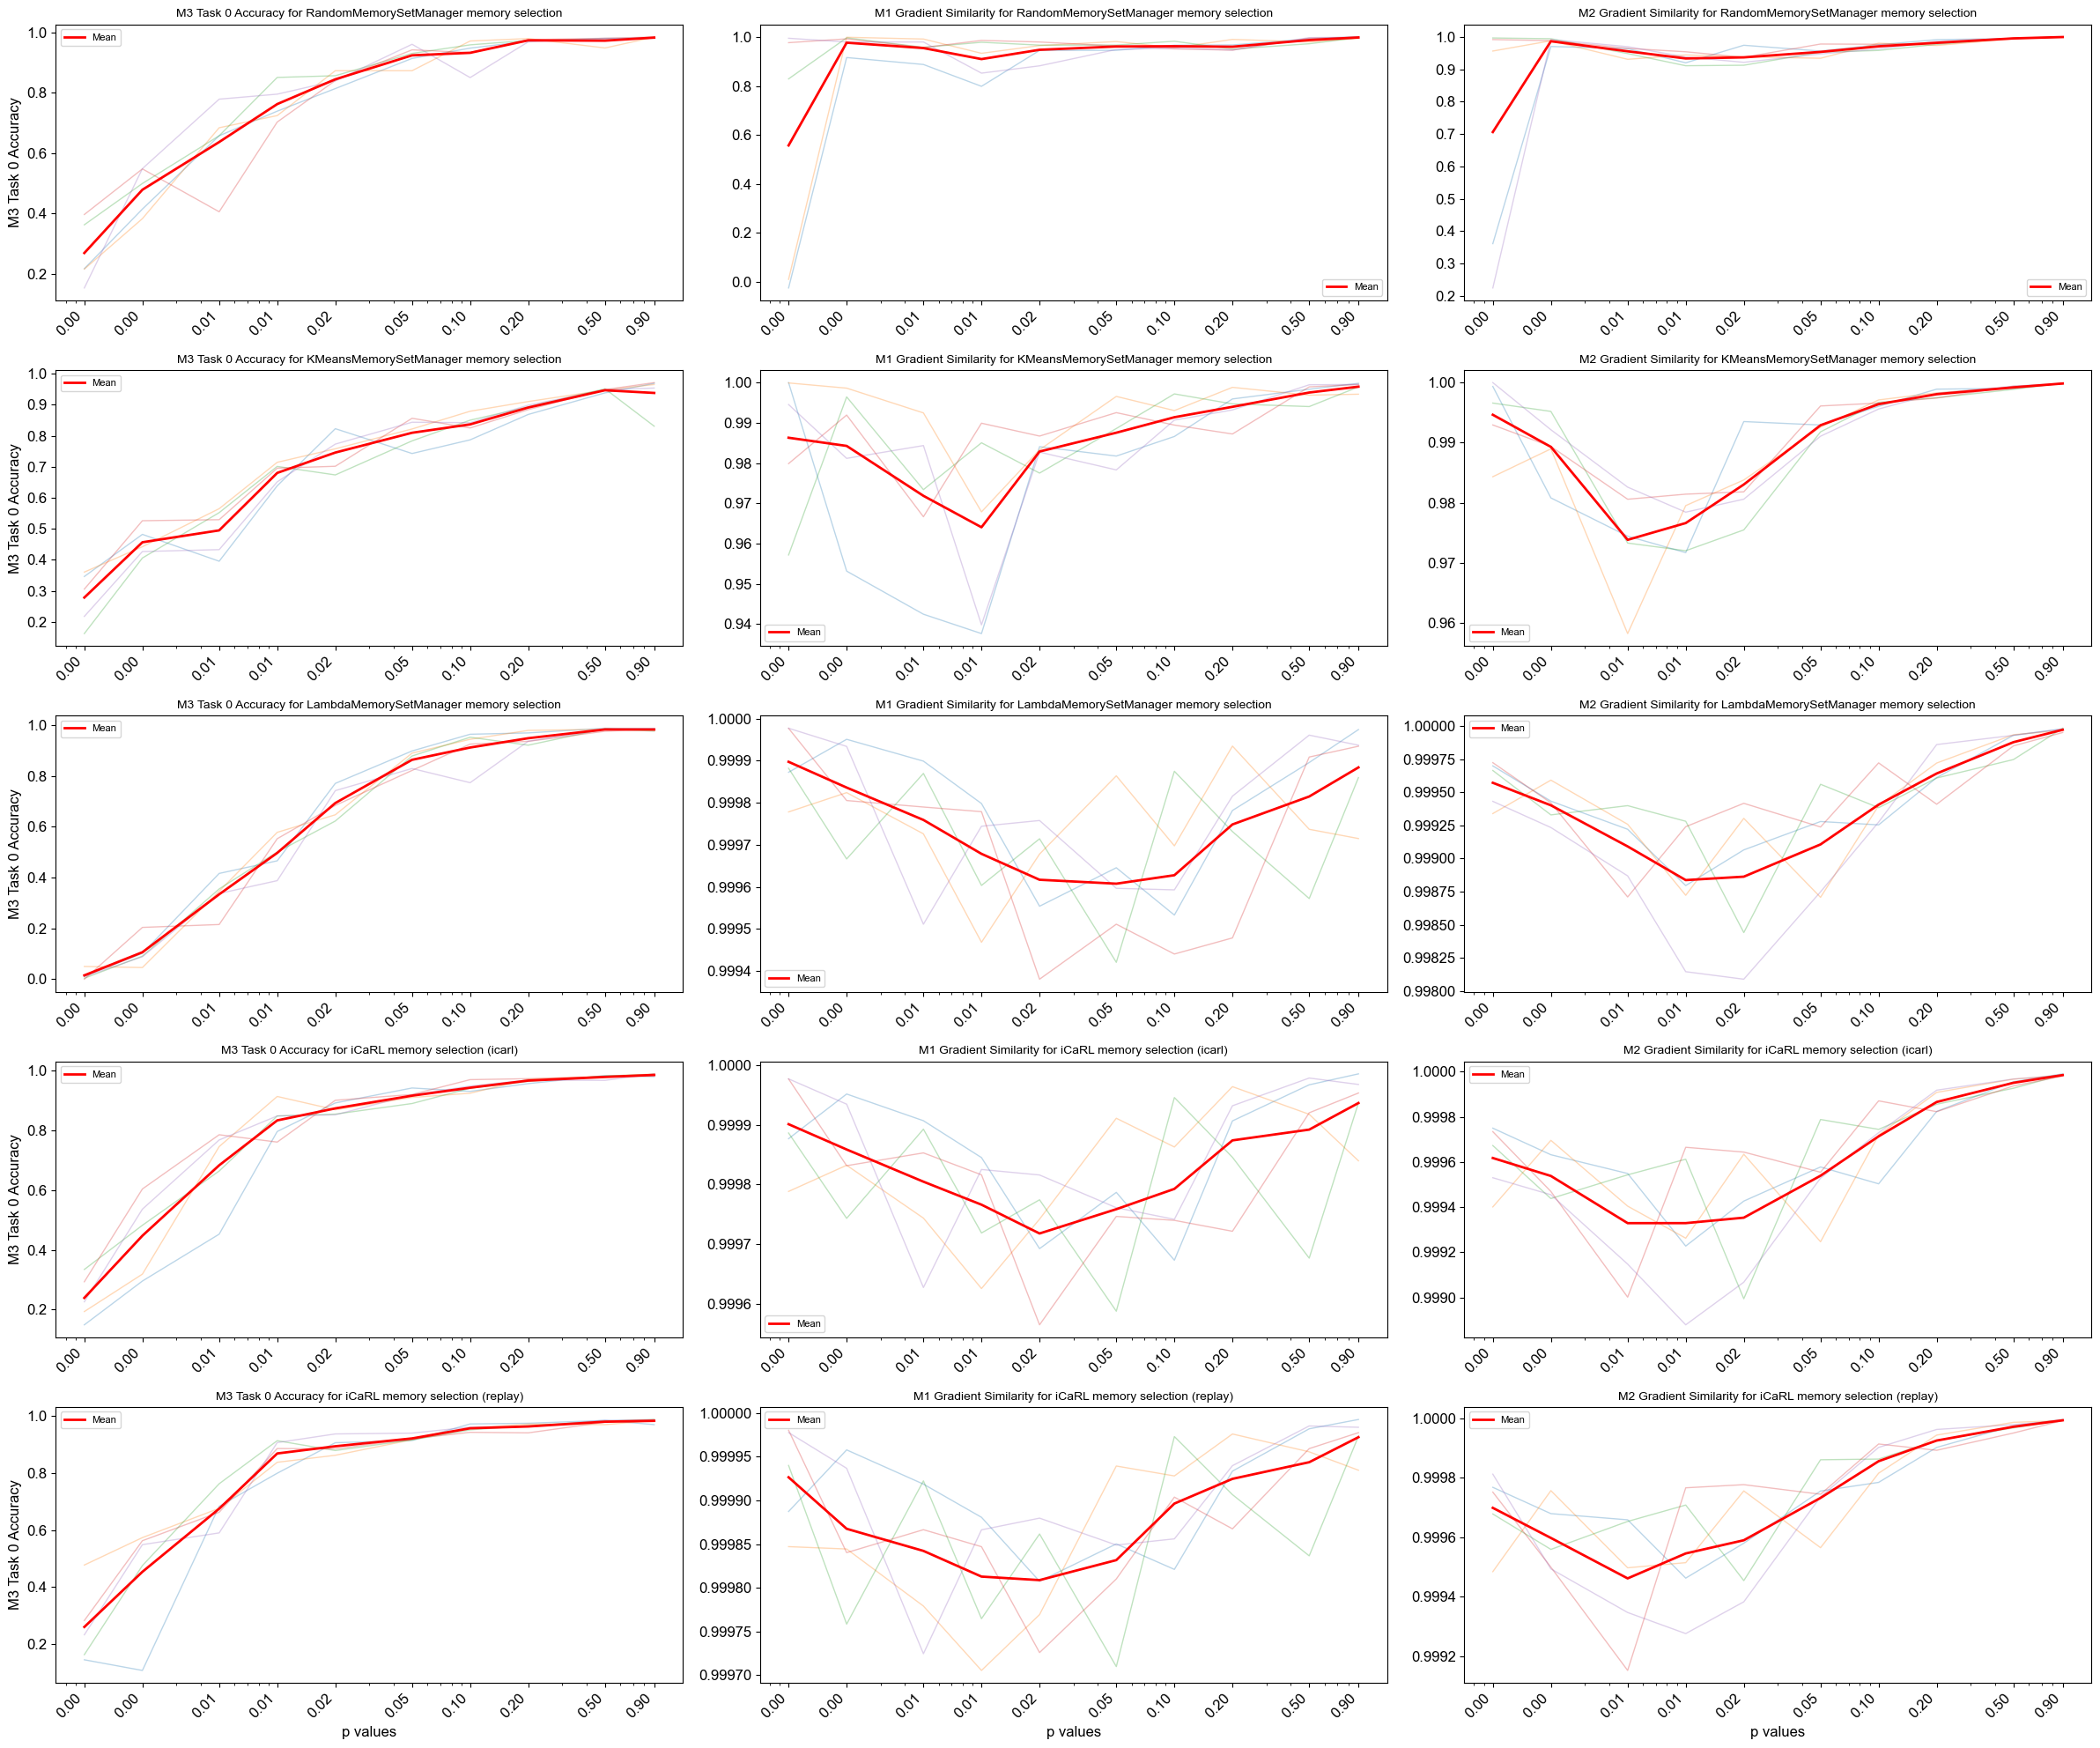

In [36]:

def plot_all_metrics(aggregated_results, dataset_name):
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12
    
    result_dir = f'gradient_similarity/{dataset_name}/plots'
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)
    
    methods = aggregated_results['method'].unique()
    p_vals = sorted(aggregated_results['p'].unique())
    
    num_methods = len(methods)
    fig, axs = plt.subplots(num_methods, 3, figsize=(24, 4*num_methods))
    
    metrics = ['M3_task', 'M1_grad_sim', 'M2_grad_sim']
    titles = [f'M3 Task {task_no} Accuracy', 'M1 Gradient Similarity', 'M2 Gradient Similarity']
    
    for method_index, method in enumerate(methods):
        method_data = aggregated_results[aggregated_results['method'] == method]
        
        for col, (metric, title) in enumerate(zip(metrics, titles)):
            if num_methods == 1:
                ax = axs[col]
            else:
                ax = axs[method_index, col]
            
            # Get the number of samples
            num_samples = len(method_data[method_data['p'] == p_vals[0]][f'{metric}_array'].values[0])
            
            for sample_index in range(num_samples):
                sample_values = [method_data[method_data['p'] == p][f'{metric}_array'].values[0][sample_index] for p in p_vals]
                ax.plot(p_vals, sample_values, alpha=0.3, linewidth=1)
            
            # Calculate and plot the mean
            mean_values = [np.mean(method_data[method_data['p'] == p][f'{metric}_array'].values[0]) for p in p_vals]
            ax.plot(p_vals, mean_values, color='red', linewidth=2, label='Mean')
            
            ax.set_xscale('log')
            ax.set_title(f'{title} for {method}', fontsize=10)
            ax.legend(fontsize=8)
            
            ax.set_xticks(p_vals)
            ax.set_xticklabels([f'{p:.2f}' for p in p_vals], rotation=45, ha='right')
            
            if method_index == num_methods - 1:  # Last row
                ax.set_xlabel('p values')
            
            if col == 0:  # First column
                ax.set_ylabel(title)
    
    plt.tight_layout()
    plt.savefig(f'{result_dir}/{OUTPUT_DIR}/{params['exp_name'][0]}/all_metrics_methods.png')
    plt.show()

plot_all_metrics(aggregated_results, 'dataset_name')

In [37]:
aggregated_results

,p,method,samples,M3_task_avg,M3_task_std,M3_task_array,M1_grad_sim_avg,M1_grad_sim_std,M1_grad_sim_array,M2_grad_sim_avg,M2_grad_sim_std,M2_grad_sim_array
0,0.100,RandomMemorySetManager memory selection,5,0.932009,0.042839,"[0.9475177304964539, 0.9711583924349881, 0.958...",0.961856,0.011373,"[0.9658919444418153, 0.9553945262197044, 0.982...",0.970670,0.008867,"[0.9756358756480263, 0.9804091837863181, 0.957..."
1,0.100,KMeansMemorySetManager memory selection,5,0.836596,0.030411,"[0.7867612293144208, 0.8789598108747045, 0.850...",0.991399,0.003565,"[0.986612421464286, 0.9930545698103009, 0.9971...",0.996378,0.000528,"[0.9960215648064912, 0.9970775427605528, 0.996..."
2,0.100,LambdaMemorySetManager memory selection,5,0.911395,0.070315,"[0.9635933806146572, 0.9437352245862884, 0.951...",0.999628,0.000149,"[0.9995328009413125, 0.9996973069997076, 0.999...",0.999406,0.000167,"[0.9992537295607504, 0.999398987916244, 0.9993..."
3,0.100,iCaRL memory selection (icarl),5,0.942790,0.015832,"[0.9304964539007092, 0.9243498817966903, 0.940...",0.999793,0.000098,"[0.9996729798933472, 0.9998629367526233, 0.999...",0.999713,0.000118,"[0.9995028983903602, 0.9997191488395217, 0.999..."
4,0.100,iCaRL memory selection (replay),5,0.956501,0.009804,"[0.9716312056737588, 0.9569739952718677, 0.950...",0.999896,0.000053,"[0.9998211074127552, 0.9999280765591606, 0.999...",0.999855,0.000049,"[0.9997843087089368, 0.9998151888587761, 0.999..."
5,0.500,RandomMemorySetManager memory selection,5,0.972199,0.012255,"[0.9801418439716312, 0.9479905437352246, 0.974...",0.987116,0.009619,"[0.9919849816066719, 0.9796078532765983, 0.972...",0.995195,0.000770,"[0.9949819519371241, 0.9941501073620651, 0.995..."
6,0.500,KMeansMemorySetManager memory selection,5,0.946572,0.004486,"[0.9380614657210402, 0.9470449172576832, 0.951...",0.997537,0.001947,"[0.998355730988473, 0.9968812916537613, 0.9940...",0.999156,0.000209,"[0.9990046009724955, 0.9992144045319058, 0.998..."
7,0.500,LambdaMemorySetManager memory selection,5,0.982506,0.003967,"[0.9872340425531915, 0.9829787234042553, 0.984...",0.999815,0.000143,"[0.9998954320321704, 0.9997366890368058, 0.999...",0.999878,0.000073,"[0.9999293351407851, 0.9999336284228154, 0.999..."
8,0.500,iCaRL memory selection (icarl),5,0.978723,0.005837,"[0.983451536643026, 0.9815602836879432, 0.9820...",0.999892,0.000111,"[0.9999672572451188, 0.999917779259822, 0.9996...",0.999950,0.000016,"[0.9999550933941032, 0.9999665449019127, 0.999..."
9,0.500,iCaRL memory selection (replay),5,0.979480,0.005663,"[0.9839243498817967, 0.9692671394799054, 0.981...",0.999944,0.000055,"[0.9999819907054484, 0.9999556396217263, 0.999...",0.999971,0.000012,"[0.9999743906019966, 0.9999861135286537, 0.999..."
